## **DATA ANALYSIS PYTHON PROJECT - BLINKIT ANALYSIS**

#### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

### **Import Raw Data**

### Sample Data

In [2]:
df = pd.read_csv("C:/Users/Rehman khan k/Downloads/blinkit_data.csv")
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [3]:
df.tail(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8513,Regular,DRY23,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,NaN,42.9112,4.0
8514,low fat,FDA11,Baking Goods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,NaN,94.7436,4.0
8515,low fat,FDK38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,NaN,149.1734,4.0
8516,low fat,FDO38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,NaN,78.9986,4.0
8517,low fat,FDG32,Fruits and Vegetables,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,NaN,222.3772,4.0
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


### Size of Data

In [4]:
print ("Size of data:",df.shape)

Size of data: (8523, 12)


### Columns

In [5]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

### Data Types

In [6]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

### Data Cleaning

In [7]:
# ========================================
# Data Cleaning Script for Blinkit Dataset
# ========================================
# Load data from your path
df = pd.read_csv("C:/Users/Rehman khan k/Downloads/blinkit_data.csv")

# -------------------------------
# 1. Handle Missing Values
# -------------------------------

# Fill missing Item Weight with mean
df["Item Weight"] = df["Item Weight"].fillna(df["Item Weight"].mean())

# Fill missing Outlet Size with mode (most common value)
if df["Outlet Size"].isnull().sum() > 0:
    df["Outlet Size"] = df["Outlet Size"].fillna(df["Outlet Size"].mode()[0])

# -------------------------------
# 2. Standardize Categorical Values
# -------------------------------

# Clean Item Fat Content categories
df["Item Fat Content"] = df["Item Fat Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

# -------------------------------
# 3. Handle Outliers
# -------------------------------

# Replace 0 in Item Visibility with mean
df["Item Visibility"] = df["Item Visibility"].replace(0, df["Item Visibility"].mean())

# -------------------------------
# 4. Remove Duplicates
# -------------------------------
df = df.drop_duplicates()

# -------------------------------
# 5. Feature Engineering
# -------------------------------

# Convert Establishment Year to Outlet Age
df["Outlet Age"] = 2025 - df["Outlet Establishment Year"]

# -------------------------------
# 6. Final Checks
# -------------------------------
print("Missing Values:\n", df.isnull().sum())
print("\nUnique Values in Item Fat Content:\n", df["Item Fat Content"].unique())
print("\nShape after cleaning:", df.shape)

# Save cleaned dataset in same folder 
df.to_csv("C:/Users/Rehman khan k/Downloads/blinkit_data_cleaned.csv", index=False)
print("\n Cleaned dataset saved as 'blinkit_data_cleaned.csv' in Downloads")


Missing Values:
 Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Sales                        0
Rating                       0
Outlet Age                   0
dtype: int64

Unique Values in Item Fat Content:
 ['Regular' 'Low Fat']

Shape after cleaning: (8523, 13)

 Cleaned dataset saved as 'blinkit_data_cleaned.csv' in Downloads


### **CLEANED DATA**

In [8]:
df = pd.read_csv("C:/Users/Rehman khan k/Desktop/Blinkit Project/blinkit_data_cleaned.csv")
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating,Outlet Age
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.100000,145.4786,5.0,13
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.800000,115.3492,5.0,3
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.850000,165.0210,5.0,15
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.150000,126.5046,5.0,25
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.600000,55.1614,5.0,10
5,Low Fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.890000,102.4016,5.0,5
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.800000,81.4618,5.0,14
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.700000,96.0726,5.0,10
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.750000,124.1730,5.0,25
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,12.857645,181.9292,5.0,27


In [9]:
df.tail(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating,Outlet Age
8513,Regular,DRY23,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,12.857645,42.9112,4.0,27
8514,Low Fat,FDA11,Baking Goods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,12.857645,94.7436,4.0,27
8515,Low Fat,FDK38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,12.857645,149.1734,4.0,27
8516,Low Fat,FDO38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,12.857645,78.9986,4.0,27
8517,Low Fat,FDG32,Fruits and Vegetables,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,12.857645,222.3772,4.0,27
8518,Low Fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.066132,12.857645,164.5526,4.0,27
8519,Low Fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,12.857645,241.6828,4.0,27
8520,Low Fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,12.857645,86.6198,4.0,27
8521,Regular,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,12.857645,97.8752,4.0,27
8522,Regular,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.066132,12.857645,112.2544,4.0,27


In [10]:
# checks null values in the data
df.isnull().sum()

Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Sales                        0
Rating                       0
Outlet Age                   0
dtype: int64

In [11]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF':'Low Fat',
                                                         'low fat':'Low Fat',
                                                        'reg':'Regular'})

In [12]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


In [13]:
df.duplicated().sum()

np.int64(0)

### **BUSINESS REQUIREMENTS**

#### **KPI's REQUIREMENTS**

In [14]:
#Total Sales
total_sales = df['Sales'].sum()

#Average Sales
avg_sales = df['Sales'].mean()

#Number of items sold
no_of_items_sold = df['Sales'].count()

#Average Ratings 
avg_ratings = df['Rating'].mean()

#Display

print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Sales: ${avg_sales:,.1f}")
print(f"no of items sold: {no_of_items_sold:,.0f}")
print(f"avg_ratings: {avg_ratings:,.1f}")

Total Sales: $1,201,681
Average Sales: $141.0
no of items sold: 8,523
avg_ratings: 4.0


### **CHARTS REQUIREMENTS**

#### **Total sales by Fat content**

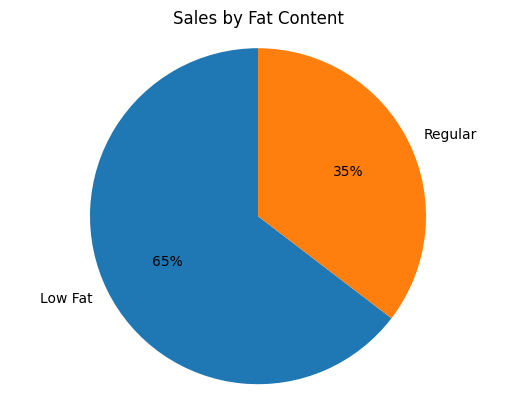

In [15]:
sales_by_fat = df.groupby('Item Fat Content') ['Sales'].sum()

plt.pie(sales_by_fat, labels = sales_by_fat.index,
       autopct = '%.0f%%',
        startangle = 90)
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

### **Total Sales by Item Type**

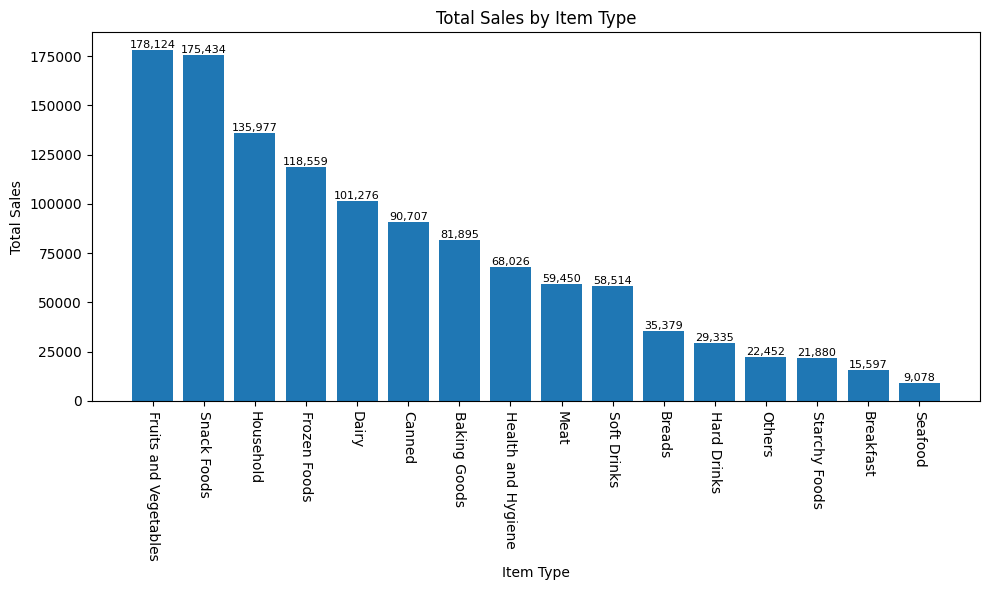

In [16]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation=-90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()  # Moved outside the loop
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

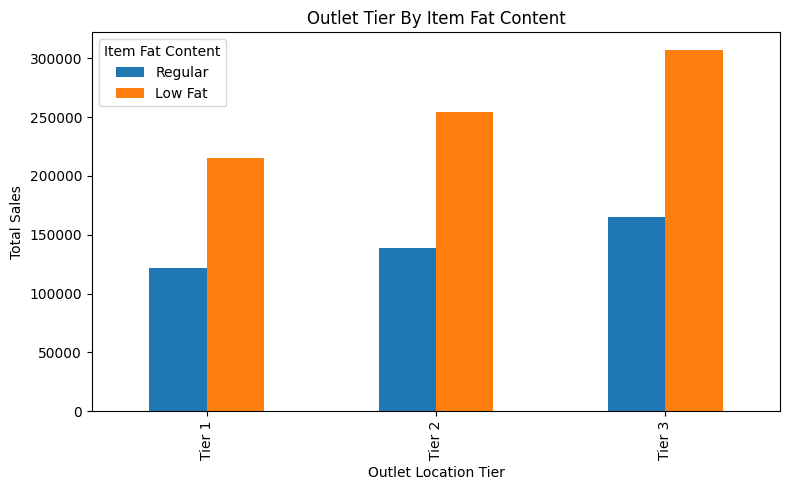

In [17]:
### **Fat Content by Outlet for Total Sales**

grouped = df.groupby(['Outlet Location Type', 'Item Fat Content']) ['Sales'].sum().unstack()
grouped = grouped[['Regular','Low Fat']]

ax = grouped.plot(kind='bar', figsize=(8,5), title='Outlet Tier By Item Fat Content')

plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show

### **Total Sales Outlet Establishment**

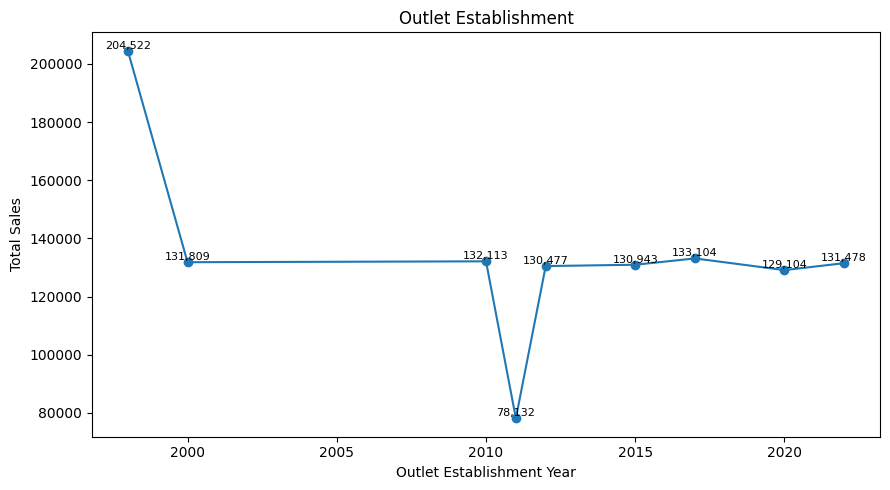

In [18]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

# Add data labels
for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout() 
plt.show()

### **Sales by Outlet Size**

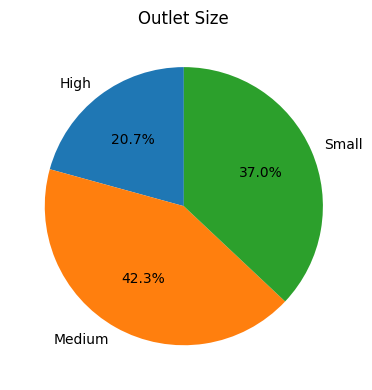

In [19]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_by_size, labels=sales_by_size.index, autopct='%1.1f%%', startangle=90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

### **Sales By Outlet Locations**

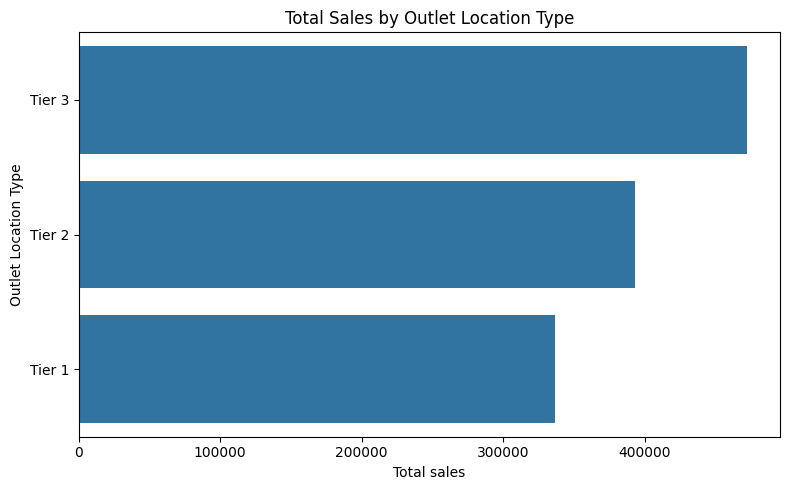

In [20]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('Sales' , ascending=False)

plt.figure(figsize=(8, 5)) 
ax = sns.barplot(x='Sales', y='Outlet Location Type', data=sales_by_location)

plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Total sales')
plt.ylabel('Outlet Location Type')

plt.tight_layout()
plt.show()

In [21]:

# 1. Basic Statistics
print("\nBasic Statistics:")
print(df.describe(include="all"))


Basic Statistics:
       Item Fat Content Item Identifier              Item Type  \
count              8523            8523                   8523   
unique                2            1559                     16   
top             Low Fat           FDW13  Fruits and Vegetables   
freq               5517              10                   1232   
mean                NaN             NaN                    NaN   
std                 NaN             NaN                    NaN   
min                 NaN             NaN                    NaN   
25%                 NaN             NaN                    NaN   
50%                 NaN             NaN                    NaN   
75%                 NaN             NaN                    NaN   
max                 NaN             NaN                    NaN   

        Outlet Establishment Year Outlet Identifier Outlet Location Type  \
count                 8523.000000              8523                 8523   
unique                        NaN   

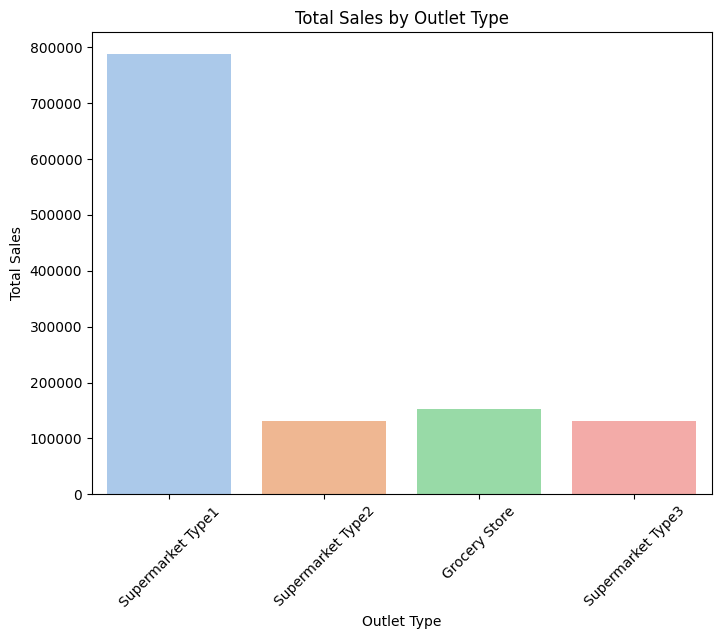

In [22]:
plt.figure(figsize=(8,6))
sns.barplot(x="Outlet Type", y="Sales", data=df, estimator=sum, errorbar=None, 
            palette="pastel", hue="Outlet Type", legend=False)
plt.title("Total Sales by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


In [24]:

# Find max sales value
max_sales = df["Sales"].max()
print("Max Sales in dataset:", max_sales)

# Create 3 bins automatically (Low, Medium, High)
df["Sales_Class"] = pd.cut(
    df["Sales"],
    bins=[-1, max_sales/3, 2*max_sales/3, max_sales],
    labels=["Low", "Medium", "High"]
)

print(df["Sales_Class"].value_counts())


# Features and target
X = df.drop(columns=["Sales", "Item Identifier", "Sales_Class"])
y = df["Sales_Class"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# F1 Score
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Max Sales in dataset: 266.8884
Sales_Class
Medium    4069
High      2546
Low       1908
Name: count, dtype: int64
F1 Score: 0.5525205826207382

Classification Report:
               precision    recall  f1-score   support

        High       0.51      0.44      0.47       495
         Low       0.59      0.31      0.41       387
      Medium       0.59      0.78      0.67       823

    accuracy                           0.57      1705
   macro avg       0.56      0.51      0.52      1705
weighted avg       0.57      0.57      0.55      1705



#### Precision tells how often the model is right when predicting Low/Medium/High Sales.
#### Recall tells how many of the actual Low/Medium/High Sales outlets were caught.
#### F1 balances both.
#### Support shows how many outlets were truly Low/Medium/High.

### 
# 1. Overall accuracy is 57%, indicating moderate predictive performance.
# 2. Weighted F1 score is 0.55, showing the model performs better on dominant classes.
# 3. "Medium" class has the highest recall (0.78) and F1 score (0.67), likely due to its larger sample size.
# 4. "Low" class has good precision (0.59) but poor recall (0.31), meaning many actual "Low" cases are missed.
# 5."High" class shows balanced but modest performance (F1 score: 0.47)